In [55]:
from langgraph.graph import StateGraph,START,END

from typing import TypedDict

In [56]:
#Define State
class TemperatureState(TypedDict):
    temp_celsius:float
    temp_farenheit:float
    weather_status:str

In [57]:
def convert_temp(state:TemperatureState)->TemperatureState:
    celsius=state['temp_celsius']

    farenheit=(celsius*9/5)+32

    state['temp_farenheit']=round(farenheit,2)
    return state


In [58]:
def label_weather(state: TemperatureState) -> TemperatureState:
    

    fahrenheit = state['temp_farenheit']
    
    if fahrenheit < 50:
        state["weather_status"] = "Cold"
    elif 50 <= fahrenheit < 77:
        state["weather_status"] = "Mild"
    elif 77 <= fahrenheit < 95:
        state["weather_status"] = "Hot"
    else:
        state["weather_status"] = "Extreme Heat"
        
    return state

In [59]:
#define and compile graph

graph=StateGraph(TemperatureState)

#add nodes
graph.add_node('convert_temp',convert_temp)

graph.add_node('label_weather',label_weather)

#add edeges to the graph
graph.add_edge(START,'convert_temp')

graph.add_edge('convert_temp','label_weather')
graph.add_edge('label_weather',END)


#compile graph

workflow=graph.compile()


In [60]:
#execute the graph
input_state={'temp_celsius':28.5}
final_state=workflow.invoke(input_state)

print(final_state)


{'temp_celsius': 28.5, 'temp_farenheit': 83.3, 'weather_status': 'Hot'}


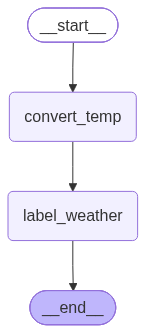

In [61]:
#visualize graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
